# Phase 1: Exploratory Data Analysis (EDA) on KITTI Dataset
## Project: Urban Object Detection for Autonomous Driving

**Authors:** Shamim Sedaghat Teymuri & Mahdi Salman

### 1. Introduction
In this notebook, we perform a comprehensive Exploratory Data Analysis (EDA) on the KITTI object detection dataset. The goal is to understand the underlying characteristics of the data, which is crucial for designing an effective preprocessing pipeline and selecting the appropriate model architecture (YOLOv8).

**Objectives:**
1.  Analyze class distribution to identify potential imbalances.
2.  Examine bounding box dimensions to understand object scales.
3.  Visualize spatial distribution to identify regions of interest (ROI).
4.  Assess scene complexity (crowdedness).

### 2. Data Loading & Parsing
We start by loading the dataset labels. The labels are in YOLO format (class_id, x_center, y_center, width, height), all normalized between 0 and 1. We parse these files and store the attributes in lists for further analysis.

In [27]:
import os
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Configuration
labels_path = '../data/labels/train'
class_names = ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']

# Data Containers
all_classes = []
all_widths = []
all_heights = []
all_centers_x = []
all_centers_y = []
objects_per_image = []

# Load Data
label_files = os.listdir(labels_path)
print(f"Loading data from {len(label_files)} files...")

for label_file in label_files:
    path = os.path.join(labels_path, label_file)
    with open(path, 'r') as f:
        lines = f.readlines()
        
    valid_objs = 0
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5: continue
        
        # Parse Class ID
        cls_id = int(parts[0])
        if cls_id < len(class_names):
            all_classes.append(class_names[cls_id])
        
        # Parse Coordinates (Normalized)
        x, y, w, h = map(float, parts[1:])
        all_centers_x.append(x)
        all_centers_y.append(y)
        all_widths.append(w)
        all_heights.append(h)
        valid_objs += 1
        
    objects_per_image.append(valid_objs)

print("Data loading complete.")

Loading data from 5985 files...
Data loading complete.


### 3. Class Distribution Analysis
**Why is this important?**
Deep learning models tend to be biased towards the majority class. In urban datasets like KITTI, we often see significantly more cars than pedestrians or cyclists.

**Analysis:**
The chart below displays the frequency of each object category. A severe imbalance (e.g., ratio > 1:10) suggests that we might need to use techniques like **Weighted Loss** or **Focal Loss** during training, or apply class-specific data augmentation.

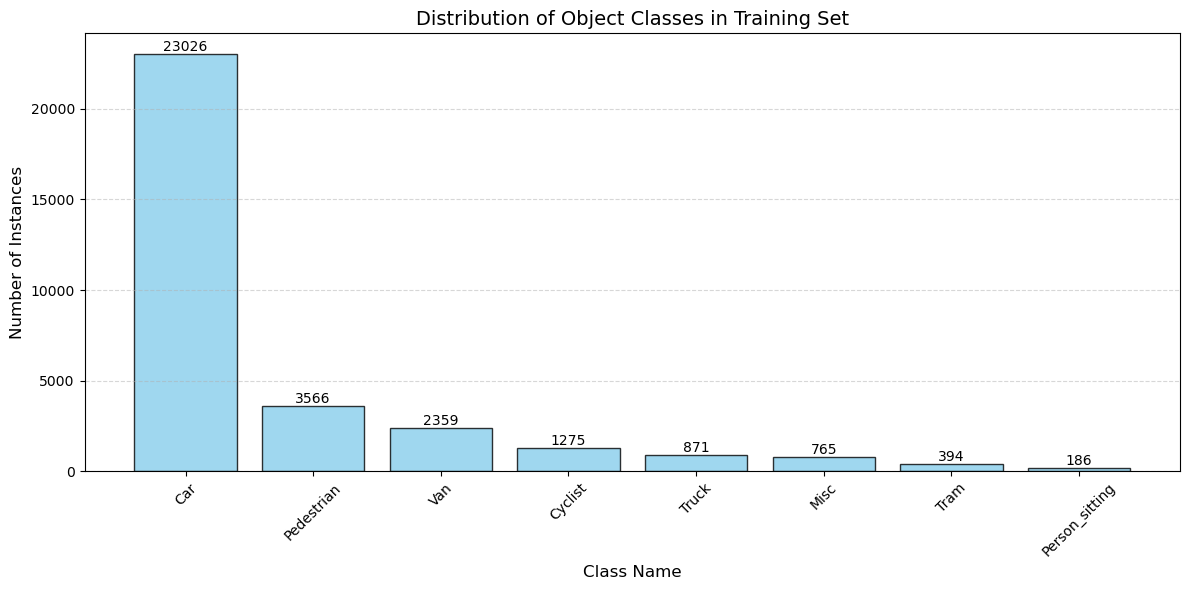

In [28]:
plt.figure(figsize=(12, 6))
counts = Counter(all_classes)
# Sort for better visualization
sorted_counts = dict(sorted(counts.items(), key=lambda item: item[1], reverse=True))

bars = plt.bar(sorted_counts.keys(), sorted_counts.values(), color='skyblue', edgecolor='black', alpha=0.8)
plt.title('Distribution of Object Classes in Training Set', fontsize=14)
plt.xlabel('Class Name', fontsize=12)
plt.ylabel('Number of Instances', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

### 4. Bounding Box Dimensions (Width vs. Height)
**Why is this important?**
Understanding the scale of objects relative to the image size is critical for choosing the input resolution and anchor boxes.

**Analysis:**
This scatter plot visualizes the width and height of every object (normalized 0-1).
- Points near (0,0) represent **Small Objects**.
- Points spread out indicate **Large Objects**.
If the majority of points are clustered below 0.1 or 0.2, it confirms that the dataset is dominated by small objects, requiring a high-resolution input (e.g., 640x640 or higher) to preserve details.

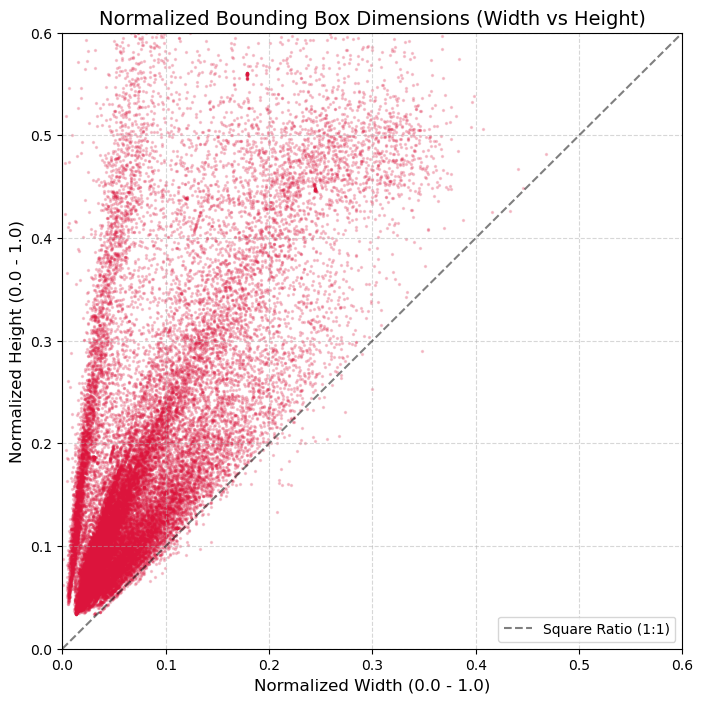

In [24]:
plt.figure(figsize=(8, 8))
plt.scatter(all_widths, all_heights, alpha=0.2, s=2, color='crimson')
plt.title('Normalized Bounding Box Dimensions (Width vs Height)', fontsize=14)
plt.xlabel('Normalized Width (0.0 - 1.0)', fontsize=12)
plt.ylabel('Normalized Height (0.0 - 1.0)', fontsize=12)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Square Ratio (1:1)')
plt.xlim(0, 0.6) # Limiting view to focus on the main cluster
plt.ylim(0, 0.6)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 5. Spatial Distribution (Object Location Heatmap)
**Why is this important?**
In autonomous driving scenarios, the camera is fixed. This means objects usually appear in predictable regions (e.g., the road surface).

**Analysis:**
The heatmap below aggregates the center coordinates of all objects.
- **Hotspots (Yellow/White):** Indicate areas with high object frequency.
- **Implication:** If objects are strictly confined to the bottom half, we might consider cropping the top part (sky) during preprocessing to reduce computation, although preserving context is usually safer.

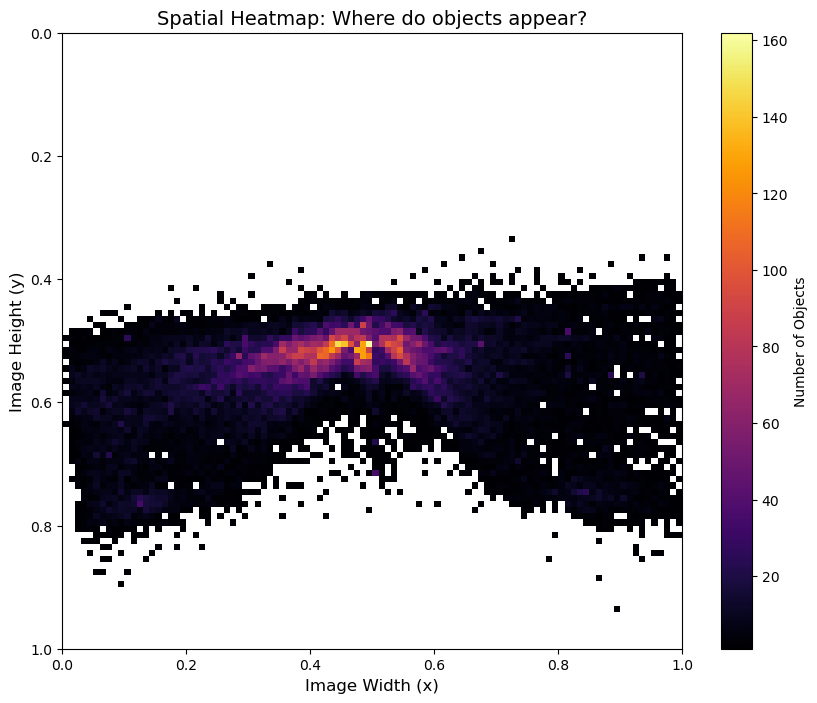

In [25]:
plt.figure(figsize=(10, 8))
# Using hist2d to create a 2D histogram (heatmap)
plt.hist2d(all_centers_x, all_centers_y, bins=100, cmap='inferno', range=[[0, 1], [0, 1]], cmin=1)
plt.colorbar(label='Number of Objects')
plt.title('Spatial Heatmap: Where do objects appear?', fontsize=14)
plt.xlabel('Image Width (x)', fontsize=12)
plt.ylabel('Image Height (y)', fontsize=12)
plt.gca().invert_yaxis() # Invert Y because image origin (0,0) is top-left
plt.show()

### 6. Scene Complexity (Objects per Image)
Why is this important?
The number of objects per image indicates the "density" of the scene.
- Low density: Risk of false positives (hallucinating objects).
- High density: Risk of missed detections due to occlusion or NMS thresholds.

Observed Analysis:
The histogram follows a Poisson-like distribution with a Mean of ~5.4 objects per image.
- Most Common: Images typically contain 1 to 3 objects.
- Crowded Scenes: There is a long tail extending to images with 15+ objects, representing busy intersections.
- Action: Since some images are crowded, we must ensure our inference configuration allows for at least 50-100 detections per frame to avoid dropping valid targets in heavy traffic.

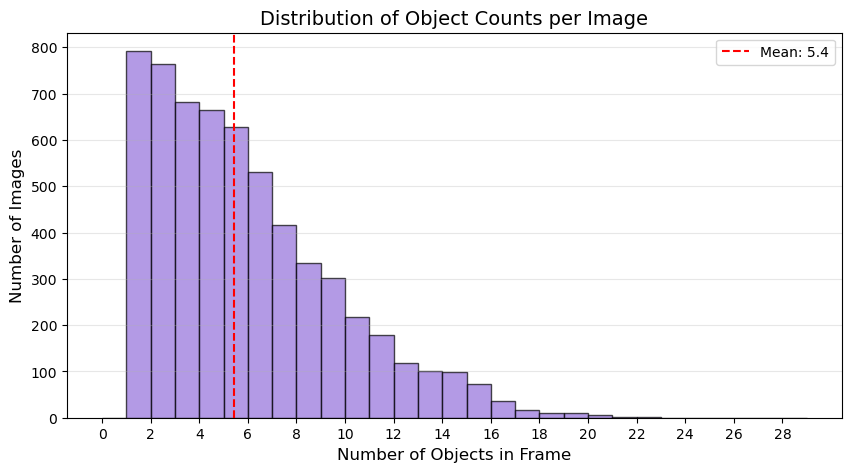

In [26]:
plt.figure(figsize=(10, 5))
plt.hist(objects_per_image, bins=range(0, 30), color='mediumpurple', edgecolor='black', alpha=0.7)
plt.title('Distribution of Object Counts per Image', fontsize=14)
plt.xlabel('Number of Objects in Frame', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(range(0, 30, 2))
# Add mean line
mean_val = np.mean(objects_per_image)
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### 7. Aspect Ratio Distribution
Why is this important?
Aspect Ratio (Width / Height) acts as a geometric signature for object classes.

Observed Analysis:
The histogram is clearly Multimodal (has multiple peaks), confirming different object geometries:
1.  Peak at ~0.3 - 0.4: Represents Tall & Thin objects (Pedestrians, Cyclists).
2.  Peak at ~1.5 - 1.8: Represents Wide objects (Cars, Vans).
3.  The "Square" Gap: There are relatively fewer objects with a perfect 1.0 ratio compared to the extremes.
- Action: If we use standard YOLO anchors, they might not cover the "Tall/Thin" pedestrians well. We should recalculate anchors using K-Means Clustering on this dataset for Phase 2.

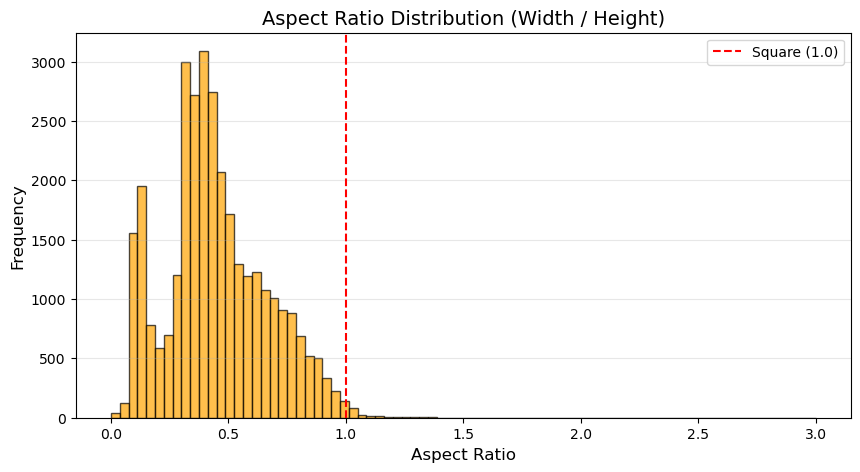

In [29]:
aspect_ratios = [w / h for w, h in zip(all_widths, all_heights) if h > 0]

plt.figure(figsize=(10, 5))
plt.hist(aspect_ratios, bins=80, range=(0, 3), color='orange', edgecolor='black', alpha=0.7)
plt.title('Aspect Ratio Distribution (Width / Height)', fontsize=14)
plt.xlabel('Aspect Ratio', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(1.0, color='red', linestyle='dashed', linewidth=1.5, label='Square (1.0)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### 8. Object Area Distribution
Why is this important?
This metric classifies objects into Small, Medium, and Large (COCO standard). Small objects usually yield lower mAP.

Observed Analysis:
We use a Logarithmic Scale because small objects vastly outnumber large ones.
- The Skew: The graph is heavily skewed to the left. The highest bars are in the region of 0.00 to 0.05 (extremely small areas).
- Implication: A significant portion of our ground truth occupies less than 5% of the image pixels.
- Action: This confirms that Small Object Detection is the primary challenge. We must not use aggressive downsampling (stride 64) in the model's backbone, or we will lose these features entirely.

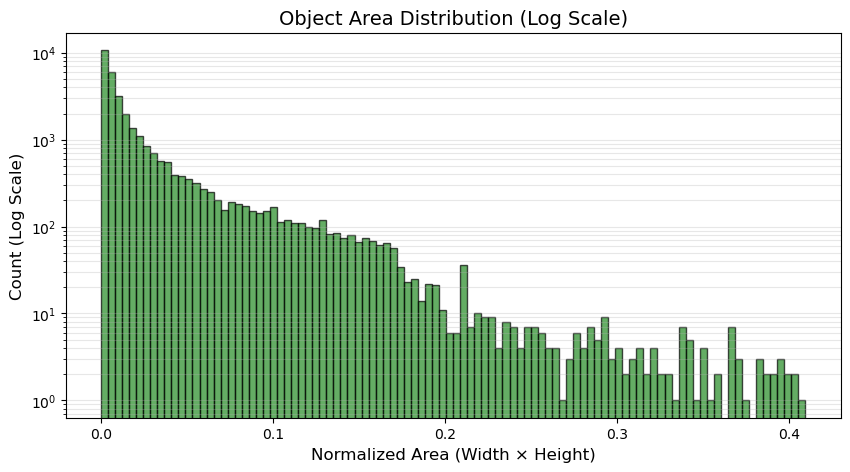

In [30]:
areas = [w * h for w, h in zip(all_widths, all_heights)]

plt.figure(figsize=(10, 5))
plt.hist(areas, bins=100, color='forestgreen', edgecolor='black', alpha=0.7)
plt.title('Object Area Distribution (Log Scale)', fontsize=14)
plt.xlabel('Normalized Area (Width × Height)', fontsize=12)
plt.ylabel('Count (Log Scale)', fontsize=12)
plt.yscale('log') # Log scale is crucial here
plt.grid(axis='y', alpha=0.3, which='both')
plt.show()